# Packages

In [ ]:
!pip install diffusers transformers accelerate --quiet
!pip install datasets --quiet
!pip install ftfy regex tqdm --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


import csv
import gc
import json
import os
import shutil
import time
import clip
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import defaultdict
from PIL import Image
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
from tqdm import tqdm
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from google.colab import drive
from google.colab import files

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


# Loading and Preprocessing Data

In [ ]:
start = time.time()
# Create a directory to store the dataset
!mkdir -p coco_dataset/images coco_dataset/annotations

# Download 2017 train images
!wget http://images.cocodataset.org/zips/train2017.zip -P coco_dataset/
!unzip -q coco_dataset/train2017.zip -d coco_dataset/images/

# Download 2017 validation images (optional)
!wget http://images.cocodataset.org/zips/val2017.zip -P coco_dataset/
!unzip -q coco_dataset/val2017.zip -d coco_dataset/images/

# Download annotations (includes captions)
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P coco_dataset/
!unzip -q coco_dataset/annotations_trainval2017.zip -d coco_dataset/annotations/

end = time.time()
print(f"Time taken: {end - start:.2f} seconds")

--2025-04-27 21:25:10--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.91.36, 16.182.72.249, 52.216.238.131, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.91.36|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘coco_dataset/train2017.zip’

train2017.zip       100%[===================>]  18.01G  95.3MB/s    in 3m 13s  

2025-04-27 21:28:23 (95.4 MB/s) - ‘coco_dataset/train2017.zip’ saved [19336861798/19336861798]

--2025-04-27 21:30:20--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.27.239, 3.5.22.74, 3.5.27.117, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.27.239|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘coco_dataset/val2017.zip’

val2017.zip         10

In [ ]:
def prepare_coco_caption_file(annotation_path, output_json, max_captions=None):
    import json

    with open(annotation_path, "r") as f:
        annotations = json.load(f)

    image_id_to_file = {img["id"]: img["file_name"] for img in annotations["images"]}
    pairs = []

    for ann in annotations["annotations"]:
        image_id = ann["image_id"]
        caption = ann["caption"]
        file_name = image_id_to_file.get(image_id)
        if file_name:
            pairs.append({
                "file_name": file_name,
                "caption": caption
            })
        if max_captions and len(pairs) >= max_captions:
            break

    with open(output_json, "w") as f:
        json.dump(pairs, f, indent=2)

    print(f"Saved {len(pairs)} image-caption pairs to {output_json}")

In [ ]:
start = time.time()
prepare_coco_caption_file(
    annotation_path="coco_dataset/annotations/annotations/captions_train2017.json",
    output_json="coco_train_captions_cleaned.json",
    max_captions=None
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Saved 591753 image-caption pairs to coco_train_captions_cleaned.json
Time taken: 3.52 seconds


In [ ]:
start = time.time()
prepare_coco_caption_file(
    annotation_path="coco_dataset/annotations/annotations/captions_val2017.json",
    output_json="coco_val_captions_cleaned.json",
    max_captions=None
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Saved 25014 image-caption pairs to coco_val_captions_cleaned.json
Time taken: 0.14 seconds


In [ ]:
def clean_caption_file(caption_file, image_folder, output_file):
    """
    Cleans a COCO-style caption file by:
    - Removing entries with missing image files
    - Skipping unreadable or corrupt images
    - Ignoring empty or whitespace-only captions
    """
    with open(caption_file, "r") as f:
        data = json.load(f)

    cleaned = []
    skipped = 0

    for item in tqdm(data, desc=f"Verifying {caption_file}"):
        image_path = os.path.join(image_folder, item["file_name"])

        if not os.path.exists(image_path):
            skipped += 1
            continue

        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            skipped += 1
            continue

        if item["caption"].strip() == "":
            skipped += 1
            continue

        cleaned.append(item)

    with open(output_file, "w") as f:
        json.dump(cleaned, f, indent=2)

    print(f"{len(cleaned)} valid image-caption pairs saved to '{output_file}'")
    print(f"{skipped} entries skipped due to missing/broken images or empty captions")

In [ ]:
clean_caption_file(
    caption_file="coco_train_captions_cleaned.json",
    image_folder="coco_dataset/images/train2017",
    output_file="coco_train_cleaned_verified.json"
)

Verifying coco_train_captions_cleaned.json: 100%|██████████| 591753/591753 [00:41<00:00, 14317.31it/s]


591753 valid image-caption pairs saved to 'coco_train_cleaned_verified.json'
0 entries skipped due to missing/broken images or empty captions


In [ ]:
clean_caption_file(
    caption_file="coco_val_captions_cleaned.json",
    image_folder="coco_dataset/images/val2017",
    output_file="coco_val_cleaned_verified.json"
)

Verifying coco_val_captions_cleaned.json: 100%|██████████| 25014/25014 [00:01<00:00, 14379.94it/s]


25014 valid image-caption pairs saved to 'coco_val_cleaned_verified.json'
0 entries skipped due to missing/broken images or empty captions


In [ ]:
# Load full cleaned COCO
with open("coco_train_cleaned_verified.json", "r") as f:
    data = json.load(f)

# Group captions by image
image_to_captions = defaultdict(list)
for entry in data:
    image_to_captions[entry["file_name"]].append(entry["caption"])

# Pick 40k images, and 2 captions each
all_images = list(image_to_captions.keys())
random.shuffle(all_images)
selected_images = all_images[:40000]

new_dataset = []
for img in selected_images:
    captions = image_to_captions[img]
    chosen_captions = random.sample(captions, 2) if len(captions) >= 2 else captions
    for caption in chosen_captions:
        new_dataset.append({"file_name": img, "caption": caption})

# Save the new dataset
with open("coco_train_80k.json", "w") as f:
    json.dump(new_dataset, f, indent=2)

print(f"New dataset created with {len(new_dataset)} samples")

New dataset created with 80000 samples


# Generating Clip embeddings

In [ ]:
def generate_clip_text_embeddings(
    caption_json_path,
    output_dir,
    batch_size=16,
    part_size=10000,
    model_name="openai/clip-vit-base-patch32"
):

    # Load cleaned caption data
    with open(caption_json_path, "r") as f:
        data = json.load(f)

    captions = [entry["caption"] for entry in data]
    os.makedirs(output_dir, exist_ok=True)

    # Setup CLIP model (lighter version)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = CLIPTokenizer.from_pretrained(model_name)
    text_encoder = CLIPTextModel.from_pretrained(model_name).to(device)


    text_embeddings = []
    part_idx = 0
    total_saved = 0

    progress = tqdm(range(0, len(captions), batch_size), desc=f"Embedding {os.path.basename(caption_json_path)}")
    for i in progress:
        captions_batch = captions[i:i+batch_size]

        try:
            tokens = tokenizer(captions_batch, padding="max_length", truncation=True, return_tensors="pt").to(device)
            with torch.no_grad():
                text_features = text_encoder(**tokens).last_hidden_state
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            text_embeddings.append(text_features.cpu())

            if len(text_embeddings) * batch_size >= part_size:
                text_tensor = torch.cat(text_embeddings, dim=0)
                save_path = os.path.join(output_dir, f"text_embeddings_part_{part_idx}.pt")
                torch.save(text_tensor, save_path)
                print(f"Saved {text_tensor.shape} to {save_path}")
                total_saved += text_tensor.shape[0]
                part_idx += 1
                text_embeddings = []

        except Exception as e:
            print(f"Batch at index {i} failed: {e}")
            continue

    # Save any remaining
    if text_embeddings:
        text_tensor = torch.cat(text_embeddings, dim=0)
        save_path = os.path.join(output_dir, f"text_embeddings_part_{part_idx}.pt")
        torch.save(text_tensor, save_path)
        print(f"💾 Saved {text_tensor.shape} to {save_path}")
        total_saved += text_tensor.shape[0]

    print(f"Total embeddings saved: {total_saved}")

In [ ]:
start = time.time()
generate_clip_text_embeddings(
    caption_json_path="coco_train_80k.json",
    output_dir="clip_embeddings_train_l14",
    batch_size=16,
    part_size=60000,
    model_name="openai/clip-vit-large-patch14"
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Embedding coco_train_80k.json:  75%|███████▌  | 3754/5000 [02:17<45:43,  2.20s/it]  

Saved torch.Size([60000, 77, 768]) to clip_embeddings_train_l14/text_embeddings_part_0.pt


Embedding coco_train_80k.json: 100%|██████████| 5000/5000 [02:45<00:00, 30.18it/s]


💾 Saved torch.Size([20000, 77, 768]) to clip_embeddings_train_l14/text_embeddings_part_1.pt
Total embeddings saved: 80000
Time taken: 195.55 seconds


In [ ]:
# ✅ Example usage for val
start = time.time()
generate_clip_text_embeddings(
    caption_json_path="coco_val_cleaned_verified.json",
    output_dir="clip_embeddings_val_l14",
    batch_size=16,
    part_size=60000,
    model_name="openai/clip-vit-large-patch14"
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Embedding coco_val_cleaned_verified.json: 100%|██████████| 1564/1564 [00:35<00:00, 43.96it/s]


💾 Saved torch.Size([25014, 77, 768]) to clip_embeddings_val_l14/text_embeddings_part_0.pt
Total embeddings saved: 25014
Time taken: 55.42 seconds


# Generating Latents

In [ ]:
def generate_vae_latents(
    caption_json_path,
    image_base_folder,
    output_dir,
    part_size=10000,
    model_path="CompVis/stable-diffusion-v1-4"
):
    # Load the cleaned JSON with file names
    with open(caption_json_path, "r") as f:
        data = json.load(f)

    image_paths = [os.path.join(image_base_folder, item["file_name"]) for item in data]

    # Load VAE and preprocessing pipeline
    device = "cuda" if torch.cuda.is_available() else "cpu"
    vae = AutoencoderKL.from_pretrained(model_path, subfolder="vae").to(device).eval()

    preprocess = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    os.makedirs(output_dir, exist_ok=True)

    latents = []
    part_idx = 0
    total_saved = 0

    for i, path in enumerate(tqdm(image_paths, desc="Encoding VAE latents")):
        try:
            img = Image.open(path).convert("RGB")
            img_tensor = preprocess(img).unsqueeze(0).to(device)

            with torch.no_grad():
                latent = vae.encode(img_tensor).latent_dist.sample() * 0.18215

            latents.append(latent.cpu())

            if len(latents) >= part_size:
                latents_tensor = torch.cat(latents)
                torch.save(latents_tensor, os.path.join(output_dir, f"vae_latents_part_{part_idx}.pt"))
                print(f"Saved {latents_tensor.shape} to vae_latents_part_{part_idx}.pt")
                total_saved += latents_tensor.shape[0]
                latents = []
                part_idx += 1

        except Exception as e:
            print(f"Skipping {path}: {e}")
            continue

    if latents:
        latents_tensor = torch.cat(latents)
        torch.save(latents_tensor, os.path.join(output_dir, f"vae_latents_part_{part_idx}.pt"))
        print(f"Saved {latents_tensor.shape} to vae_latents_part_{part_idx}.pt")
        total_saved += latents_tensor.shape[0]

    print(f"Total VAE latents saved: {total_saved}")

In [ ]:
start = time.time()
generate_vae_latents(
    caption_json_path="coco_train_80k.json",
    image_base_folder="coco_dataset/images/train2017",
    output_dir="vae_latents_train",
    part_size=80000
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Encoding VAE latents: 100%|██████████| 80000/80000 [22:13<00:00, 60.00it/s]

Saved torch.Size([80000, 4, 32, 32]) to vae_latents_part_0.pt
Total VAE latents saved: 80000
Time taken: 1336.50 seconds


In [ ]:
start = time.time()
generate_vae_latents(
    caption_json_path="coco_val_cleaned_verified.json",
    image_base_folder="coco_dataset/images/val2017",
    output_dir="vae_latents_val",
    part_size=60000  # or however many you have in val
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Encoding VAE latents: 100%|██████████| 25014/25014 [06:32<00:00, 63.66it/s]


Saved torch.Size([25014, 4, 32, 32]) to vae_latents_part_0.pt
Total VAE latents saved: 25014
Time taken: 393.93 seconds


# Training Pipeline

In [ ]:
class LDMText2ImageDataset(Dataset):
    def __init__(self, latents_dir, embeddings_dir):
        self.latent_tensors = self._load_all_parts(latents_dir)
        self.embedding_tensors = self._load_all_parts(embeddings_dir)

        assert len(self.latent_tensors) == len(self.embedding_tensors), \
            f"Mismatch: {len(self.latent_tensors)} latents vs {len(self.embedding_tensors)} embeddings"

    def _load_all_parts(self, folder):
        all_parts = sorted(
            [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".pt")]
        )
        all_data = [torch.load(p) for p in all_parts]
        return torch.cat(all_data, dim=0)

    def __len__(self):
        return len(self.latent_tensors)

    def __getitem__(self, idx):
        return {
            "latent": self.latent_tensors[idx],
            "embedding": self.embedding_tensors[idx]
        }

In [ ]:
start = time.time()
train_dataset = LDMText2ImageDataset(
    latents_dir="vae_latents_train",
    embeddings_dir="clip_embeddings_train_l14"
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Print one sample to confirm
sample = next(iter(train_loader))
print("Latent shape:", sample["latent"].shape)        # [B, 4, 32, 32]
print("Text embedding shape:", sample["embedding"].shape)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Latent shape: torch.Size([32, 4, 32, 32])
Text embedding shape: torch.Size([32, 77, 768])
Time taken: 80.63 seconds


In [ ]:
start = time.time()
val_dataset = LDMText2ImageDataset(
    latents_dir="vae_latents_val",
    embeddings_dir="clip_embeddings_val_l14"
)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Time taken: 26.50 seconds


In [ ]:
# # Device
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4, alpha=1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_A = nn.Linear(in_features, r, bias=False)
        self.lora_B = nn.Linear(r, out_features, bias=False)
        self.alpha = alpha
        self.scaling = alpha / r

    def forward(self, x):
        return self.linear(x) + self.scaling * self.lora_B(self.lora_A(x))

In [ ]:
def inject_lora_into_unet(unet, r=4, alpha=1.0):
    for name, module in unet.named_modules():
        if isinstance(module, nn.Linear):
            parent = unet
            *path, last = name.split(".")
            for p in path:
                parent = getattr(parent, p)
            lora_layer = LoRALinear(module.in_features, module.out_features, r=r, alpha=alpha)
            setattr(parent, last, lora_layer.to(unet.device))
    print("✅ Injected LoRA into all nn.Linear layers")

In [ ]:
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet").to("cuda")
inject_lora_into_unet(unet, r=4, alpha=1.0)

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

✅ Injected LoRA into all nn.Linear layers


In [ ]:
for param in unet.parameters():
    param.requires_grad = False

# Unfreeze only LoRA layers
for name, param in unet.named_parameters():
    if "lora_" in name:
        param.requires_grad = True

In [ ]:
# Optimizer: Only train LoRA weights
optimizer = AdamW(filter(lambda p: p.requires_grad, unet.parameters()), lr=1e-4)

In [ ]:
# DDIM noise scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
noise_scheduler.set_timesteps(1000)

In [ ]:
# Scheduler + Loss
lr_scheduler = CosineAnnealingLR(optimizer, T_max=10)
mse_loss = nn.MSELoss()

In [ ]:
# Trackers
train_losses = []
val_losses = []
best_val_loss = float("inf")
num_epochs = 9

Epoch 1:   0%|          | 1/2500 [00:00<23:18,  1.79it/s]

[Epoch 1 | Step 0] Train Loss: 0.1639


Epoch 1:   0%|          | 11/2500 [00:05<21:31,  1.93it/s]

[Epoch 1 | Step 10] Train Loss: 0.2207


Epoch 1:   1%|          | 21/2500 [00:10<21:24,  1.93it/s]

...

[Epoch 9 | Step 2480] Train Loss: 0.1927


Epoch 9: 100%|█████████▉| 2491/2500 [21:30<00:04,  1.93it/s]

[Epoch 9 | Step 2490] Train Loss: 0.1763


Epoch 9: 100%|██████████| 2500/2500 [21:35<00:00,  1.93it/s]


Epoch 9 Avg Train Loss = 0.1636
Epoch 9 Avg Validation Loss = 0.1655
Saved LoRA adapter at epoch 9


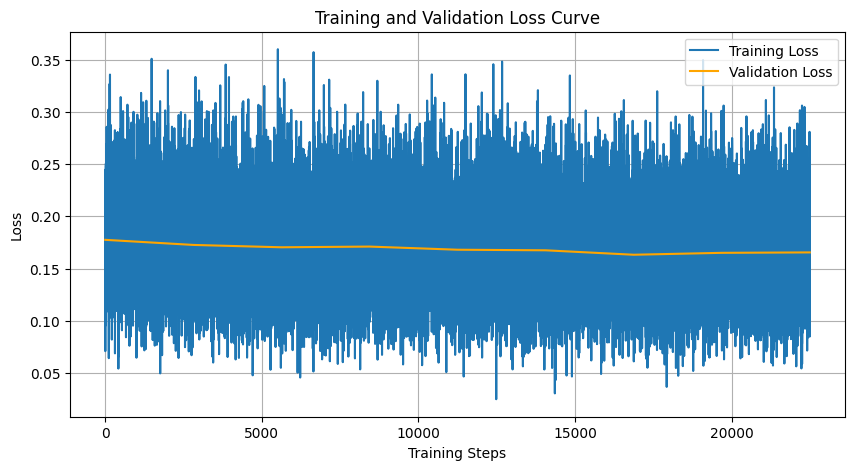

In [ ]:
with open("training_log.csv", "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Epoch", "Train Loss", "Validation Loss", "Epoch Time (sec)"])

    # Training Loop
    for epoch in range(num_epochs):
        start_time = time.time()
        unet.train()
        total_train_loss = 0

        for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            try:
                latents = batch["latent"].float().to(device)
                text_embed = batch["embedding"].float().to(device)
                noise = torch.randn_like(latents)

                if torch.rand(1).item() < 0.1:
                    text_embed = torch.zeros_like(text_embed)

                timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
                noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)


                noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embed).sample


                loss = mse_loss(noise_pred, noise)
                optimizer.zero_grad()
                loss.backward()
                clip_grad_norm_(unet.parameters(), max_norm=1.0)
                optimizer.step()

                total_train_loss += loss.item()
                train_losses.append(loss.item())

                if step % 10 == 0:
                    print(f"[Epoch {epoch+1} | Step {step}] Train Loss: {loss.item():.4f}")

            except RuntimeError as e:
                print(f"[Step {step}] Runtime error: {e}")
                torch.cuda.empty_cache()
                continue

        avg_train_loss = total_train_loss / len(train_loader)
        print(f"Epoch {epoch+1} Avg Train Loss = {avg_train_loss:.4f}")

        # Validation
        unet.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                latents = batch["latent"].float().to(device)
                text_embed = batch["embedding"].float().to(device)
                noise = torch.randn_like(latents)

                timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
                noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

                noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embed).sample
                val_loss = mse_loss(noise_pred, noise)
                total_val_loss += val_loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} Avg Validation Loss = {avg_val_loss:.4f}")

        epoch_time = time.time() - start_time

        writer.writerow([epoch+1, avg_train_loss, avg_val_loss, epoch_time])

        # Save LoRA checkpoint
        lora_weights = {k: v for k, v in unet.state_dict().items() if "lora" in k}
        torch.save(lora_weights, f"lora_epoch_{epoch+1}.pt")
        print(f"Saved LoRA adapter at epoch {epoch+1}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(lora_weights, "lora_best.pt")
            print(f"Saved best LoRA model with val loss {best_val_loss:.4f}")

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(torch.linspace(0, len(train_losses), steps=len(val_losses)), val_losses, label="Validation Loss", color="orange")
plt.title("Training and Validation Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

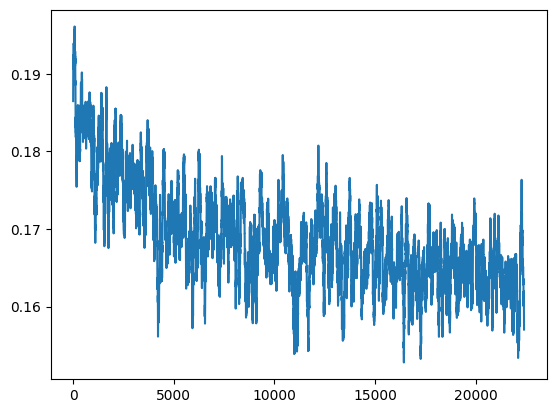

In [ ]:
import numpy as np
def smooth(x, window=100):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.plot(smooth(train_losses), label="Smoothed Train Loss")

# Inference Pipeline

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet").to(device)

In [ ]:
inject_lora_into_unet(unet, r=4, alpha=1.0)

✅ Injected LoRA into all nn.Linear layers


In [ ]:
lora_state_dict = torch.load("lora_epoch_7.pt")

In [ ]:
unet.load_state_dict(lora_state_dict, strict=False)

_IncompatibleKeys(missing_keys=['conv_in.weight', 'conv_in.bias', 'time_embedding.linear_1.linear.weight', 'time_embedding.linear_2.linear.weight', 'down_blocks.0.attentions.0.norm.weight', 'down_blocks.0.attentions.0.norm.bias', 'down_blocks.0.attentions.0.proj_in.weight', 'down_blocks.0.attentions.0.proj_in.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.norm1.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm1.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q.linear.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.linear.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v.linear.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.linear.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm2.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm2.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_q.linear.weight', 'down_blocks.0.attentions.0.transformer_blocks

In [ ]:
unet.eval()

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): LoRALinear(
      (linear): Linear(in_features=320, out_features=1280, bias=False)
      (lora_A): Linear(in_features=320, out_features=4, bias=False)
      (lora_B): Linear(in_features=4, out_features=1280, bias=False)
    )
    (act): SiLU()
    (linear_2): LoRALinear(
      (linear): Linear(in_features=1280, out_features=1280, bias=False)
      (lora_A): Linear(in_features=1280, out_features=4, bias=False)
      (lora_B): Linear(in_features=4, out_features=1280, bias=False)
    )
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0):

In [ ]:
# ✅ Load VAE Decoder
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to(device).eval()

In [ ]:
# ✅ Load CLIP (ViT-L/14)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device).eval()

In [ ]:
# ✅ Noise Scheduler
scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(100)

In [ ]:
def generate_image_from_prompt(prompt, unet, vae, tokenizer, text_encoder, scheduler, device, guidance_scale=7.5, save_dir="generated_images"):
    os.makedirs(save_dir, exist_ok=True)

    # ✅ Encode text
    with torch.no_grad():
        cond_tokens = tokenizer([prompt], padding="max_length", truncation=True, return_tensors="pt").to(device)
        cond_embed = text_encoder(**cond_tokens).last_hidden_state
        cond_embed = cond_embed / cond_embed.norm(dim=-1, keepdim=True)

        uncond_embed = torch.zeros_like(cond_embed).to(device)
        text_embed = torch.cat([uncond_embed, cond_embed], dim=0)  # [2, 77, 768]

    # ✅ Start from random noise
    latent = torch.randn(1, 4, 32, 32).to(device)

    # 🔁 Denoising
    for t in scheduler.timesteps:
        latent_in = latent.repeat(2, 1, 1, 1)
        with torch.no_grad():
            noise_pred = unet(latent_in, t, encoder_hidden_states=text_embed).sample
        noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
        latent = scheduler.step(noise_pred, t, latent).prev_sample

    # ✅ Decode to image
    with torch.no_grad():
        decoded = vae.decode(latent / 0.18215).sample

    # ✅ Post-process and save
    image = to_pil_image(decoded.squeeze().clamp(-1, 1) * 0.5 + 0.5)
    image_path = os.path.join(save_dir, f"{prompt.replace(' ', '_')[:40]}.png")
    image.save(image_path)
    print(f"🖼️ Saved: {image_path}")

    return image


🖼️ Saved: generated_images/A_beactiful_beach.png


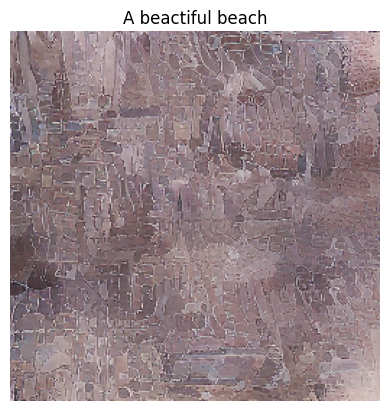

In [ ]:
prompt = "A beactiful beach"
img = generate_image_from_prompt(
    prompt=prompt,
    unet=unet,
    vae=vae,
    tokenizer=tokenizer,
    text_encoder=text_encoder,
    scheduler=scheduler,
    device=device,
    guidance_scale=8,
)

plt.imshow(img)
plt.axis("off")
plt.title(prompt)
plt.show()

# Model Evaluation

In [ ]:
prompt_file = "coco_val_cleaned_verified.json"
output_dir = "generated_1k"
os.makedirs(output_dir, exist_ok=True)

# ✅ Load 1000 prompts
with open(prompt_file, "r") as f:
    val_data = json.load(f)

sampled_prompts = [entry["caption"] for entry in val_data[:1000]]

In [ ]:

for i, prompt in enumerate(tqdm(sampled_prompts, desc="Generating")):
    try:
        # Encode text
        tokens = tokenizer([prompt], padding="max_length", truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            cond_embed = text_encoder(**tokens).last_hidden_state
            cond_embed = cond_embed / cond_embed.norm(dim=-1, keepdim=True)
            uncond_embed = torch.zeros_like(cond_embed).to(device)
            text_embed = torch.cat([uncond_embed, cond_embed], dim=0)

        # Noise
        latent = torch.randn(1, 4, 32, 32).to(device)

        # Denoising loop
        for t in scheduler.timesteps:
            latent_in = latent.repeat(2, 1, 1, 1)
            with torch.no_grad():
                noise_pred = unet(latent_in, t, encoder_hidden_states=text_embed).sample
            noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
            latent = scheduler.step(noise_pred, t, latent).prev_sample

        # Decode image
        with torch.no_grad():
            decoded = vae.decode(latent / 0.18215).sample

        image = to_pil_image(decoded.squeeze().clamp(-1, 1) * 0.5 + 0.5)
        filename = f"gen_{i:04d}.png"
        image_path = os.path.join(output_dir, filename)
        image.save(image_path)

        # Save mapping
        prompt_image_map.append({"filename": filename, "caption": prompt})

    except Exception as e:
        print(f"❌ Error with prompt {i}: {e}")
        continue

# ✅ Save mapping file
with open(os.path.join(output_dir, "captions.json"), "w") as f:
    json.dump(prompt_image_map, f, indent=2)

print("✅ Generation complete and metadata saved.")

In [ ]:
import torch
import clip
from PIL import Image
from tqdm import tqdm

# Load CLIP model (ViT-L/14)
clip_model, clip_preprocess = clip.load("ViT-L/14", device="cuda")
clip_model.eval()

In [ ]:
# ✅ Load base UNet
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet").to(device)

# ✅ Inject LoRA layers
inject_lora_into_unet(unet, r=4, alpha=1.0)

# ✅ Load LoRA weights
lora_weights = torch.load("lora_best.pt", map_location=device)
unet.load_state_dict(lora_weights, strict=False)
unet.eval()

In [ ]:
prompt_image_map = []
guidance_scale = 5

In [ ]:
def compute_clip_score(img_path, prompt, model, preprocess, device="cuda"):
    try:
        image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
        text = clip.tokenize([prompt]).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        score = torch.cosine_similarity(image_features, text_features).item()
        return score
    except Exception as e:
        print(f"❌ Failed on {img_path}: {e}")
        return None

In [ ]:
import json
import os

# Load captions
with open("generated_1k/captions.json", "r") as f:
    data = json.load(f)

clip_scores = []

for item in tqdm(data, desc="CLIP Scoring"):
    prompt = item["caption"]
    path = os.path.join("generated_1k", item["filename"])
    score = compute_clip_score(path, prompt, clip_model, clip_preprocess)
    if score is not None:
        clip_scores.append(score)

# Summary
import numpy as np
print(f"\n🔤 Average CLIP Score: {np.mean(clip_scores):.4f}")
print(f"📉 Min: {np.min(clip_scores):.4f}, 📈 Max: {np.max(clip_scores):.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.hist(clip_scores, bins=20, color="skyblue")
plt.title("CLIP Score Distribution")
plt.xlabel("CLIP Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## To check images with high clip score

In [ ]:
import json

with open("generated_1k/captions.json", "r") as f:
    caption_data = json.load(f)

In [ ]:
# Each item is a dict with score + caption + filename
scored_items = []

for item, score in zip(caption_data, clip_scores):
    scored_items.append({
        "filename": item["filename"],
        "caption": item["caption"],
        "score": score
    })

In [ ]:
top_items = sorted(scored_items, key=lambda x: x["score"], reverse=True)

for i, item in enumerate(top_items[:10]):
    print(f"{i+1}. {item['filename']} | Score: {item['score']:.4f}")
    print(f"   📝 {item['caption']}")

# Find the words frequency in the data

In [ ]:
# with open("/content/coco_val_captions_cleaned.json", "r") as f:
#     valdata = json.load(f)

# sum("forest" in item["caption"].lower() for item in annotations)